# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО:** Коновалов Матвей Александрович

**Факт о себе:** Занимаюсь безопасностью детекторов уже 3 месяца и только сейчас начал получать полноценную теоретическую базу для этого


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды. 

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300"> 
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх. 

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600"> 
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [202]:
import torch
from sklearn.metrics import root_mean_squared_error
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

 Начнем с того, что скачаем и загрузим данные:

In [3]:
#!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

In [4]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [5]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

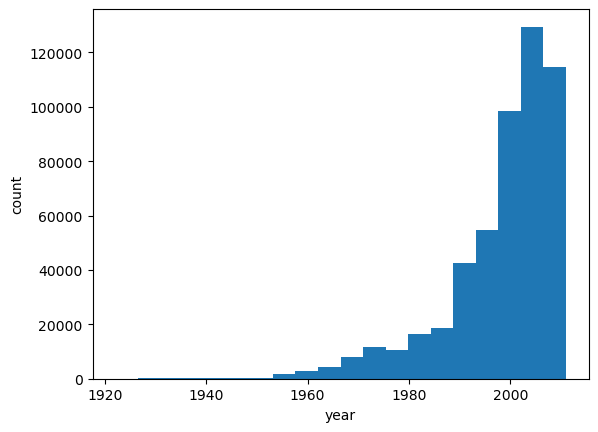

Range: 1922 - 2011
Unique values: 89


In [6]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [8]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(17)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Ridge()
model.fit(X_train, y_train)

rmse_for_model = root_mean_squared_error(y_test, model.predict(X_test))
rmse_for_model

9.47363033268409

Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [10]:
const_res = np.mean(y_train)

best_rmse_metric = root_mean_squared_error(y_test, np.ones(y_test.shape) * const_res)
best_rmse_metric

10.845542969687791

Ура-ура-ура, даже глупенькая моделька лучше константного предсказания, мы таки чем-то полезным в дата саенсе занимаемся

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию. 

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [12]:
X_train.shape, y_train.shape

((289881, 90), (289881,))

In [13]:
class LinReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(90, 1)
        )

    def forward(self, x):
        return self.model(x)

# Была использована идея из https://proproprogs.ru/nn_pytorch/pytorch-optimizatory-realizaciya-sgd-na-pytorch
class optimizer():
    def __init__(self, params, lr):
        self.params = params
        self.lr = lr

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        for param in self.params:
            param.data -= param.grad * self.lr

def rmse(y_pred, y_true):
    return torch.sqrt(torch.mean((y_true - y_pred)**2))

In [16]:
def training_epoch(model, optimizer, loss_fn, train_loader):
    train_loss, train_acc = 0.0, 0.0
    model.train()
    for x, y in tqdm(train_loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return train_loss

@torch.no_grad()
def validation_epoch(model, loss_fn, val_loader):
    val_loss, val_acc = 0.0, 0.0
    model.eval()
    for x, y in tqdm(val_loader):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        val_loss += loss.item()

    return val_loss

def train(model, optimizer, loss_fn, train_loader, val_loader, num_epochs):
    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(model, optimizer, loss_fn, train_loader)
        val_loss = validation_epoch(model, loss_fn, val_loader)
        print(epoch, train_loss, val_loss)

In [15]:
train_dataset = torch.utils.data.TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train))
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

val_dataset = torch.utils.data.TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val))
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

model = LinReg().to(device)
loss_fn = rmse
optim = optimizer(model.parameters(), 1e-3)
train(model, optim, loss_fn, train_loader, val_loader, num_epochs=10)

  0%|          | 0/1133 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

1 2264227.0478515625 755411.1052246094


  0%|          | 0/1133 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

...

  0%|          | 0/378 [00:00<?, ?it/s]

9 2264226.726928711 755411.4105224609


  0%|          | 0/1133 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

10 2264226.3591308594 755410.8251953125


## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [246]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """
    train_loss, train_acc = 0.0, 0.0
    model.train()
    clear_output(wait=True)
    for x, y in tqdm(train_loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return train_loss


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    val_loss, val_acc = 0.0, 0.0
    model.eval()
    clear_output(wait=True)
    for x, y in tqdm(val_loader):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        val_loss += loss.item()


    return val_loss


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    model.eval()
    predicts = model(data_loader)
    return predicts


def train(model, optimizer, criterion, train_loader, val_loader, epochs, writer=None):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """
    train_losses, val_losses = [], []
    for epoch in tqdm(range(1, epochs + 1), desc="Epoch"):
        train_loss = training_epoch(model, optimizer, criterion, train_loader)
        val_loss = validation_epoch(model, criterion, val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if writer is not None:
            writer.add_scalar('Loss/train', train_loss, epoch)
            writer.add_scalar('Loss/val', val_loss, epoch)

    return train_losses, val_losses

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [23]:
in_features = X_train.shape[1]
out_features = y_train.max() - y_train.min() + 1
start_date = y_train.min()
print(f'in_features: {in_features}, out_features: {out_features}')
print(f'start_date: {start_date}')

in_features: 90, out_features: 90
start_date: 1922


In [225]:
%load_ext tensorboard
%tensorboard --logdir logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Я попробовал поставить num_workers > 0, напрямую Jupyter такое не поддерживает и пришлось согласно совету со [StackOverflow](https://stackoverflow.com/a/77415133) выносить создание датасета в отдельный файл.

Что интересно, на моем макбуке даже макимальное рекомендованное разрабами торча значение, то есть num_workers=12, показало себя хуже, чем использование num_workers=0 и получение батчей в основном потоке. Скорее всего, это связано с высокой скоростью памяти мака и плохой работой питона с несколькими потоками.

In [302]:
def create_loaders(x_train, y_train, x_val, y_val, batch_size=64, shuffle=True):
    train_dataset = torch.utils.data.TensorDataset(torch.Tensor(x_train), torch.Tensor(y_train))
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0
    )

    val_dataset = torch.utils.data.TensorDataset(torch.Tensor(x_val), torch.Tensor(y_val))
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0
    )

    return train_loader, val_loader

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F

class RMSELoss(nn.Module): # Взят отсюда: https://discuss.pytorch.org/t/rmse-loss-function/16540/3
    def __init__(self, eps=1e-6):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self,yhat,y):
        loss = torch.sqrt(self.mse(yhat,y) + self.eps)
        return loss

class FirstNet(nn.Module):
    def __init__(self):
        super(FirstNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, out_features),
            nn.Softmax(dim=1) # Чтобы получались действительно вероятности
        )

    def forward(self, x):
        return self.model(x)

    def predict(self, x):
        return self.model(x) + start_date

y_train_classes = torch.LongTensor(y_train - start_date)
y_train_probs = F.one_hot(y_train_classes, num_classes=out_features).float()

y_val_classes = torch.LongTensor(y_val - start_date)
y_val_probs = F.one_hot(y_val_classes, num_classes=out_features).float()

train_loader, val_loader = create_loaders(X_train, y_train_probs, X_val, y_val_probs)

criterion = RMSELoss()
first_net = FirstNet().to(device)
optimizer = torch.optim.SGD(first_net.parameters(), lr=1e-3)
writer = SummaryWriter('logs/first_net')
train_losses_1, val_losses_1 = train(first_net, optimizer, criterion, train_loader, val_loader, epochs=4, writer=writer)
writer.flush()

In [186]:
def plot_losses(train_losses, val_losses, figsize=(12,8)):
    ax = plt.figure(figsize=(12, 8))
    plt.plot(train_losses, c='b', label='train')
    plt.plot(val_losses, c='r', label='val')
    plt.legend(loc='upper right')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.yscale('log')
    plt.title('Значения функции потерь при обучении')
    plt.show()

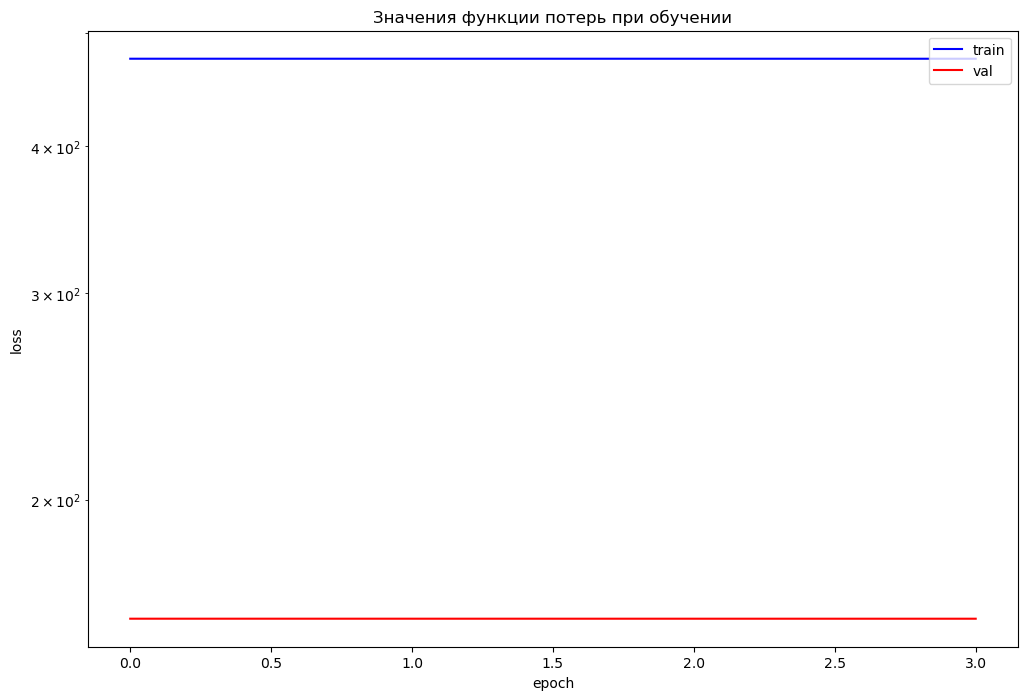

In [142]:
plot_losses(train_losses_1, val_losses_1)

In [143]:
train_losses_1, val_losses_1

([475.06043230742216,
  475.0535851046443,
  475.04675977677107,
  475.0397257730365],
 [158.35357843339443,
  158.3512995392084,
  158.34896512329578,
  158.3466751202941])

**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** *коммент до того, как я дописал и посмотрел результаты:* в целом писать классификатор было больно и сложно; даже не смотря на этот факт, у нас очевиднейшая задача регрессии, а мы зачем-то сделали это классификатором; а вдруг у нас на тесте появится песня, вышедшая раньше или позже тестовых? Как будто, достаточно умная нейронка сможет выявить зависимости и тенденции в музыке и предсказать нужный год даже в таком случае, а классификатором никогда не получится такого добиться

*Коммент после просмотра результатов*: какой ужас, оно совершенно не обучилось. Дальше посмотрим, возможно, так быть не должно и придется всё переписать, но пока верим, что классификация здесь not the way to go. А если уж мы и хотим идти её путем, так хотя бы функцию потерь было здорово поменять.

**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [144]:
class SecondNet(nn.Module):
    def __init__(self):
        super(SecondNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.model(x)

y_train_reshaped, y_val_reshaped = y_train.reshape(-1, 1), y_val.reshape(-1, 1)
train_loader, val_loader = create_loaders(X_train, y_train_reshaped, X_val, y_val_reshaped)

criterion = nn.MSELoss()

second_net = SecondNet().to(device)
optimizer = torch.optim.SGD(second_net.parameters(), lr=1e-5)
writer = SummaryWriter('logs/second_net')
train_losses_2, val_losses_2 = train(second_net, optimizer, criterion, train_loader, val_loader, epochs=4, writer=writer)
writer.flush()

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

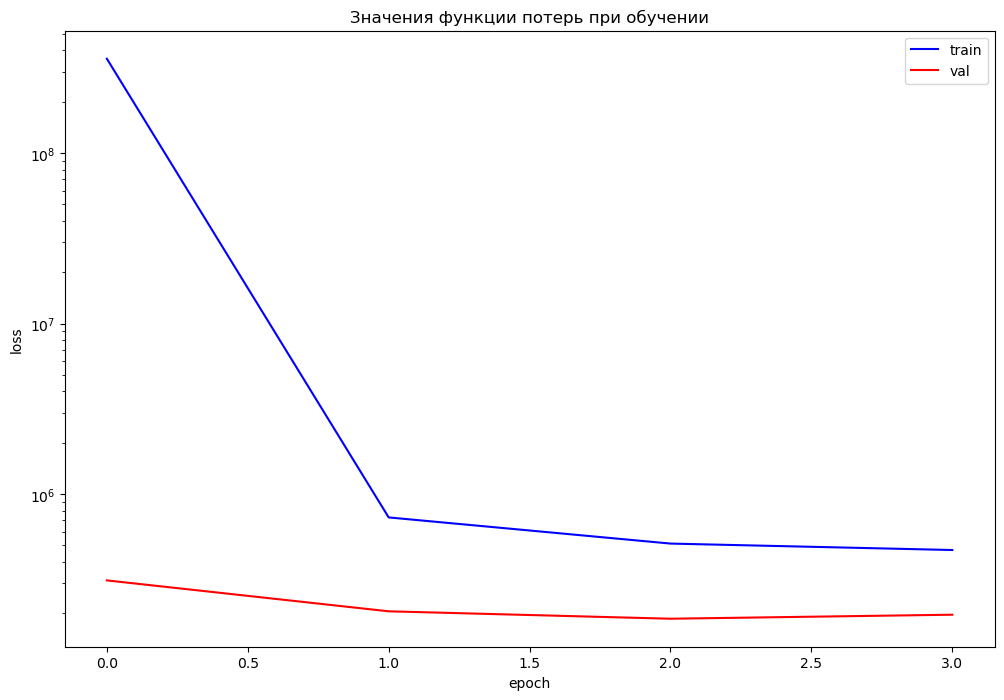

In [146]:
plot_losses(train_losses_2, val_losses_2)

In [147]:
train_losses_2, val_losses_2

([357433706.50421906, 729558.6286964417, 512471.192073822, 469769.37046813965],
 [311682.3502922058, 205324.2925682068, 185770.08979034424, 196133.877494812])

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** при 1е-3 получили NaN в лоссах, видимо, значения получались слишком большими/произошел взрыв градиентов, но в целом хотя бы, по сравнению с предыдущим вариантов, действительно видно, что у нас происходит обучение. Пока так себе, но происходит! Возможно, имело бы смысл повысить количество эпох.

Ещё одним моментом, который здорово было поменять, это заскейлить сами признаки - магнитуда между ними может разниться в ~10 раз, что могло быть и хуже, но всё ещё не здорово.

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [148]:
x_min = y_train.min()
x_max = y_train.max()

def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - x_min) / (x_max - x_min)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (x_max - x_min) + x_min

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

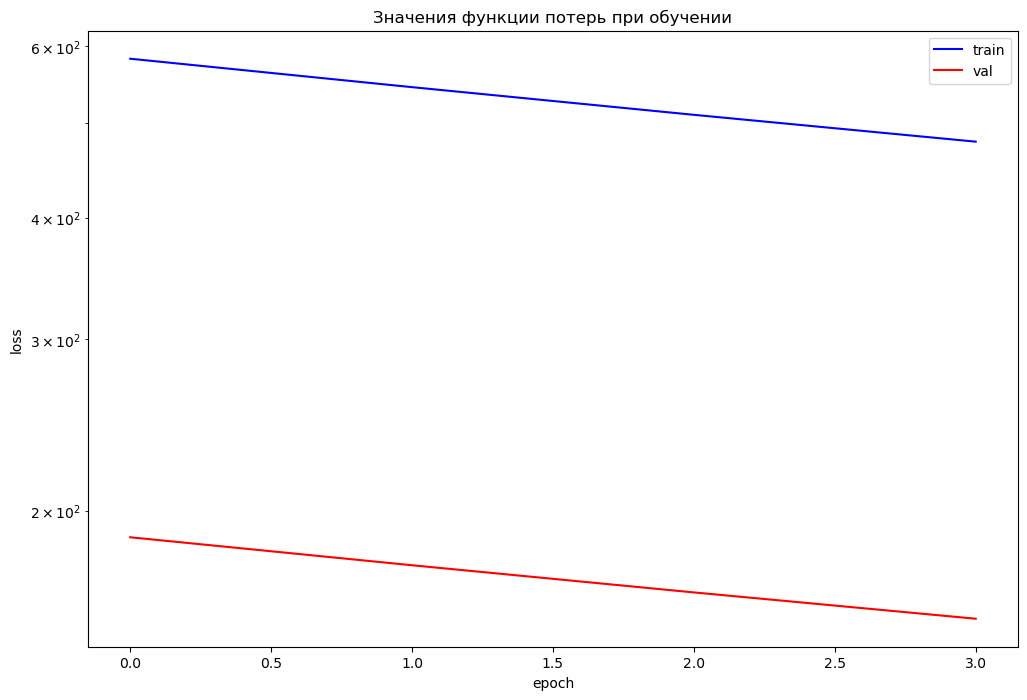

In [165]:
class ThirdNet(nn.Module):
    def __init__(self):
        super(ThirdNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

y_train_normalized, y_val_normalized = normalize(y_train).reshape(-1,1), normalize(y_val).reshape(-1,1)
train_loader, val_loader = create_loaders(X_train, y_train_normalized, X_val, y_val_normalized)

criterion = nn.MSELoss()

third_net = ThirdNet().to(device)
optimizer = torch.optim.SGD(third_net.parameters(), lr=1e-5)
writer = SummaryWriter('logs/third_net')
train_losses_3, val_losses_3 = train(third_net, optimizer, criterion, train_loader, val_loader, epochs=4, writer=writer)
writer.flush()
plot_losses(train_losses_3, val_losses_3)

In [166]:
train_losses_3, val_losses_3

([582.4277164712548, 544.5525628328323, 510.0736092478037, 478.71534387767315],
 [187.8483928218484,
  175.82638912647963,
  164.88437966257334,
  154.94104821234941])

**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

...

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

  0%|          | 0/4530 [00:00<?, ?it/s]

  0%|          | 0/1510 [00:00<?, ?it/s]

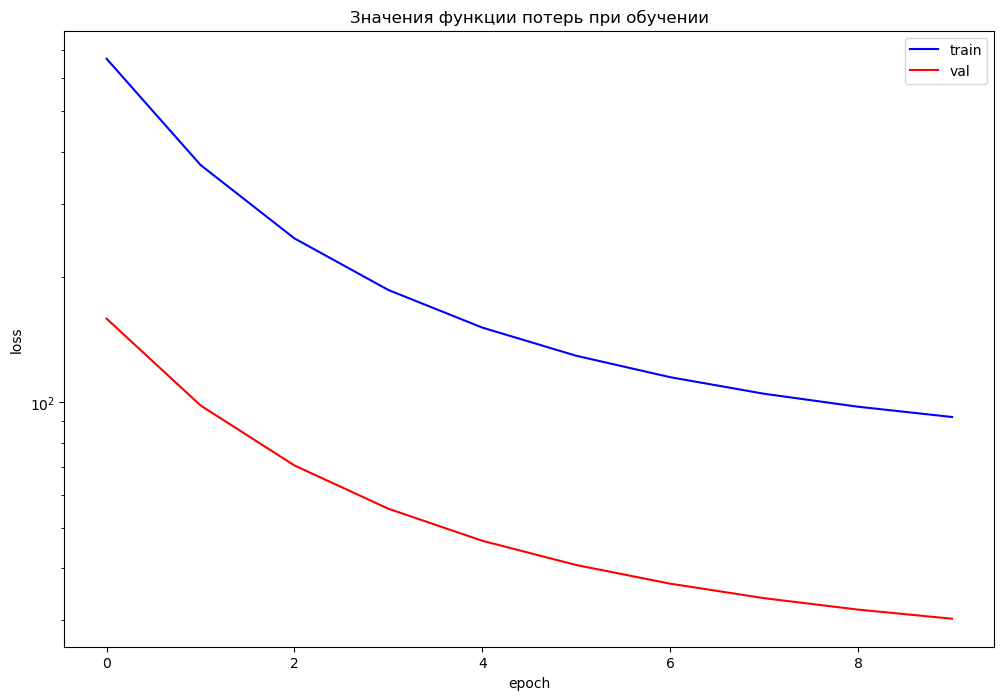

In [182]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
x_train_standardized, x_val_standardized = ss.fit_transform(X_train), ss.transform(X_val)
y_train_normalized, y_val_normalized = normalize(y_train).reshape(-1,1), normalize(y_val).reshape(-1,1)
train_loader, val_loader = create_loaders(x_train_standardized, y_train_normalized, x_val_standardized, y_val_normalized)

criterion = nn.MSELoss()
third_net = ThirdNet().to(device)
optimizer = torch.optim.SGD(third_net.parameters(), lr=1e-4)
writer = SummaryWriter('logs/third_net')

train_losses_3, val_losses_3 = train(third_net, optimizer, criterion, train_loader, val_loader, epochs=10, writer=writer)

writer.flush()
plot_losses(train_losses_3, val_losses_3)

In [231]:
def calculate_rmse(model):
    return root_mean_squared_error(y_test, denormalize(model(torch.Tensor(X_test).to(device)).detach().cpu().numpy()))

In [232]:
calculate_rmse(third_net)

12.364306990692665

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией. (было 9.47, стало 12.36 - всё ещё хуже, но одного порядка хотя бы)

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

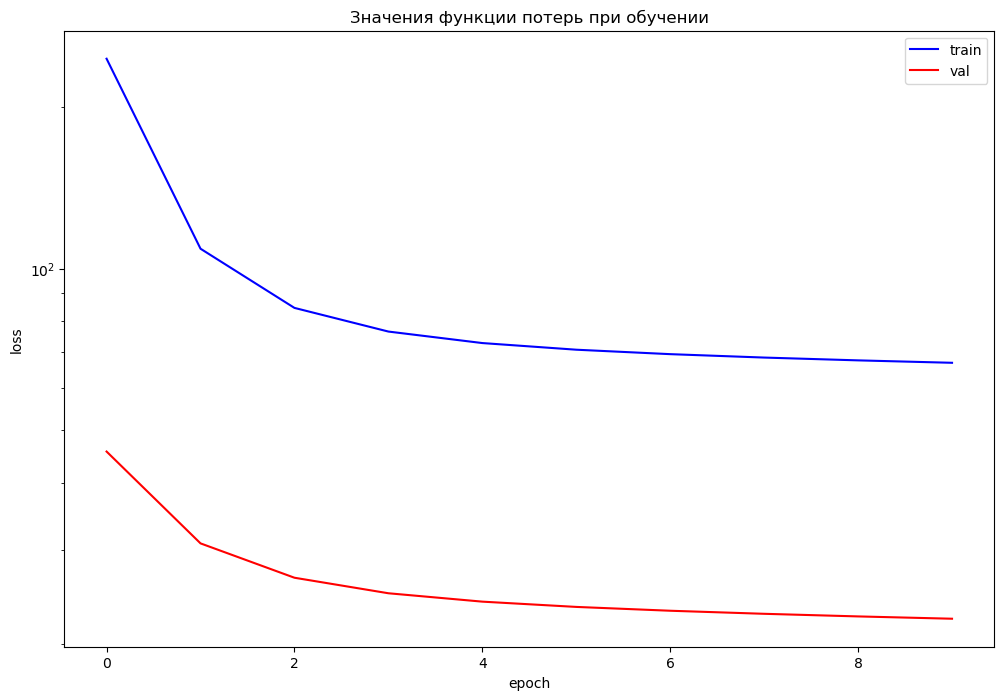

In [221]:
third_net_momentum = ThirdNet().to(device)
optimizer = torch.optim.SGD(third_net_momentum.parameters(), lr=1e-4, momentum=0.75) # Я слегка занялся подбором гиперпараметров и это получось лучшее сочетание
writer = SummaryWriter('logs/third_net_momentum')

train_losses_4, val_losses_4 = train(third_net_momentum, optimizer, criterion, train_loader, val_loader, epochs=10, writer=writer)

writer.flush()
plot_losses(train_losses_4, val_losses_4, figsize=(8, 6))

In [233]:
calculate_rmse(third_net_momentum)

10.629595389929413

  0%|          | 0/1510 [00:00<?, ?it/s]

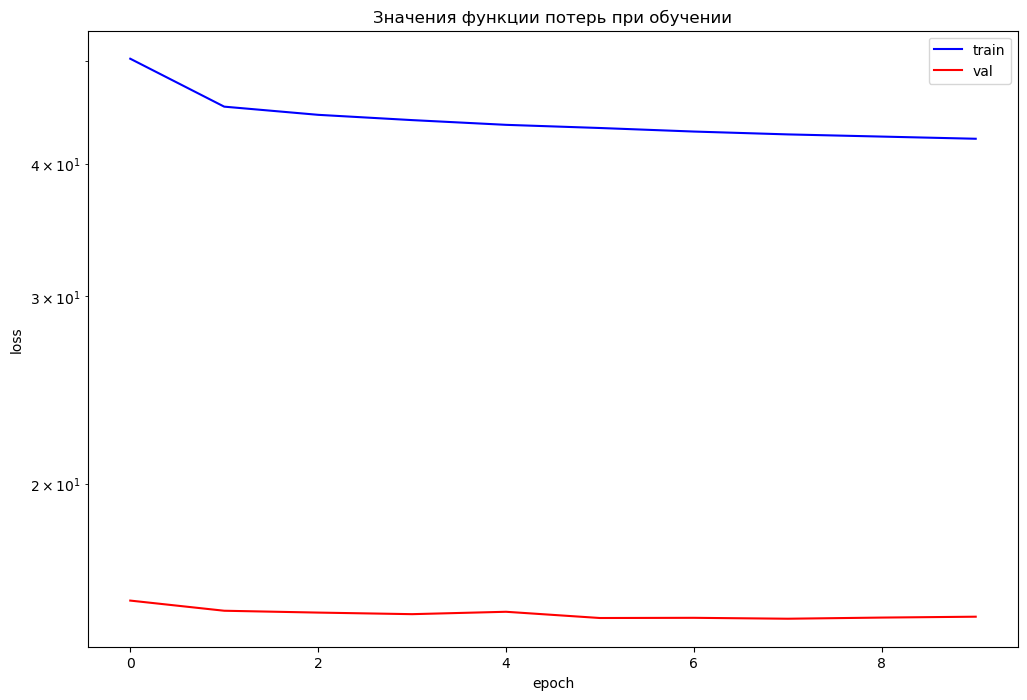

In [228]:
third_net_adam = ThirdNet().to(device)
optimizer = torch.optim.Adam(third_net_adam.parameters(), lr=1e-3)
writer = SummaryWriter('logs/third_net_adam')

train_losses_5, val_losses_5 = train(third_net_adam, optimizer, criterion, train_loader, val_loader, epochs=10, writer=writer)

writer.flush()
plot_losses(train_losses_5, val_losses_5)

In [234]:
calculate_rmse(third_net_adam)

8.863314450470577

**Мои комменты:** в Momentum пришлось заняться подбром гиперпараметров, в то время как Adam показывает лучшие результаты с первой же эпохи, ещё и сходится быстрее. Но, конечно, как графики трейна и вала у метода с momentum идут абсолютно одинаково со смещением из-за размера выборки, выглядит очень красиво, я бы распечатал и на стену этот график повесил

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

  0%|          | 0/1510 [00:00<?, ?it/s]

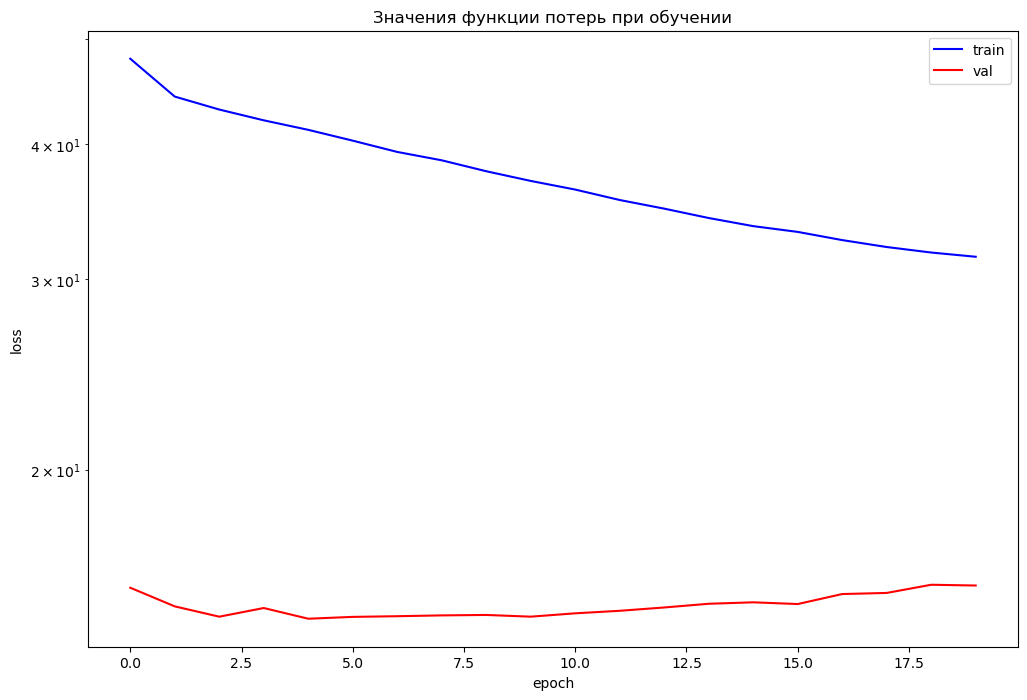

In [239]:
class FourthNet(nn.Module):
    def __init__(self):
        super(FourthNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

fourth_net = FourthNet().to(device)
optimizer = torch.optim.Adam(fourth_net.parameters(), lr=1e-3)
writer = SummaryWriter('logs/fourth_net')

train_losses_6, val_losses_6 = train(fourth_net, optimizer, criterion, train_loader, val_loader, epochs=20, writer=writer)

writer.flush()
plot_losses(train_losses_6, val_losses_6)

In [240]:
calculate_rmse(fourth_net)

9.298723421625208

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ изначально было заметно, что качество на 10 эпохах было чууууточку хуже предыдущей версии, так что логичным решением было увеличить количество эпох, отсюда первый вывод - большая модель дольше обучается. Звучит логично.

Ошибка стабильно продолжает падать на обучающей выборке, а вот на валидационной как раз около 10-й эпохи ползет вверх, RMSE на тестовой выборке так же стало больше. Это явный признак переобучения, так что второй вывод - большие модели сильнее подвержены переобучению. Действительно, с большим числом параметров, им легче попробовать "запомнить в себя" обучающую выборку, а не искать какие-то обобщающие свойства и закономерности.

Так что если заниматься исправлением переобучения не хочется, то можно довольствоваться слабенькой моделью, но с такой миром править не будешь, так что мы едем дальше.

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

In [ ]:
class DropoutNet(nn.Module):
    def __init__(self):
        super(DropoutNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

dropout_net = DropoutNet().to(device)
optimizer = torch.optim.Adam(dropout_net.parameters(), lr=1e-3)
writer = SummaryWriter('logs/dropout_net')

train_losses_7, val_losses_7 = train(dropout_net, optimizer, criterion, train_loader, val_loader, epochs=20, writer=writer) # Когда-нибудь я пойму, зачем я сохраняю все лоссы в отдельные массивы. Мб я хотел посравнивать их, но для этого в итоге служит rmse после каждой именованной модели

writer.flush()
plot_losses(train_losses_7, val_losses_7)

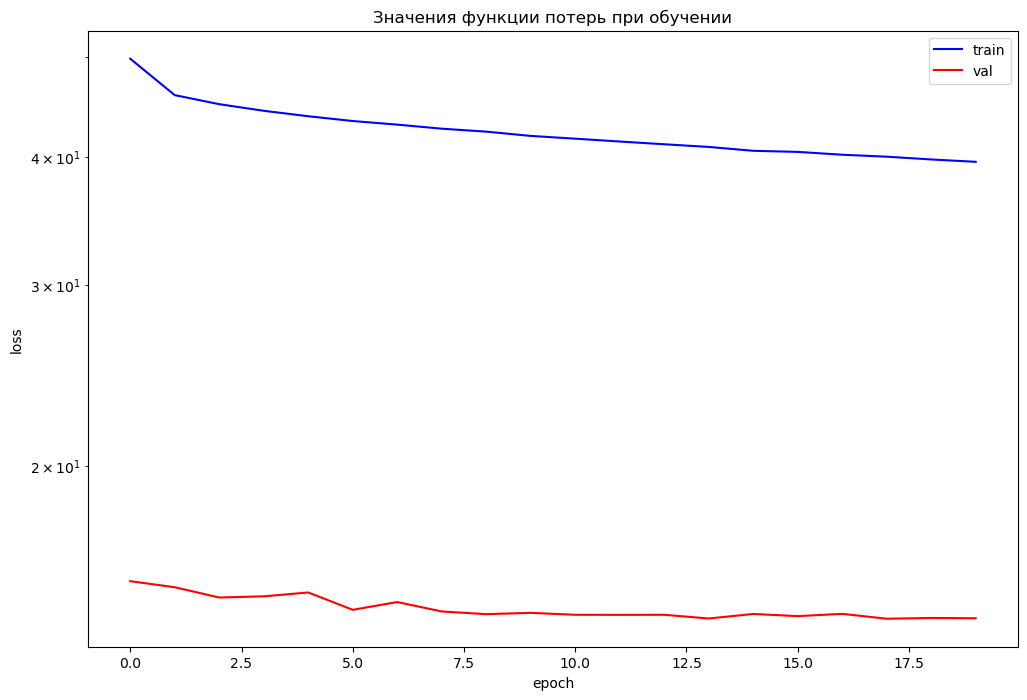

In [250]:
plot_losses(train_losses_7, val_losses_7)

In [247]:
calculate_rmse(dropout_net)

8.74721019933329

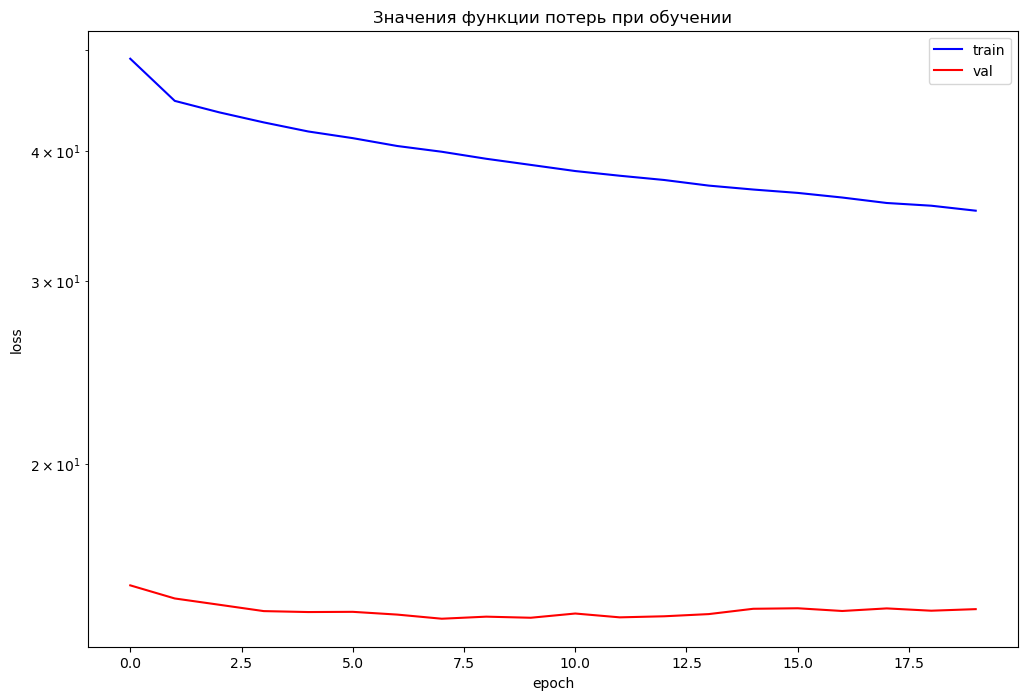

In [304]:
class BatchNormNet(nn.Module):
    def __init__(self):
        super(BatchNormNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

batchnorm_net = BatchNormNet().to(device)
optimizer = torch.optim.Adam(batchnorm_net.parameters(), lr=1e-3)
writer = SummaryWriter('logs/batchnorm_net')

train_losses_8, val_losses_8 = train(batchnorm_net, optimizer, criterion, train_loader, val_loader, epochs=20, writer=writer) # Когда-нибудь я пойму, зачем я сохраняю все лоссы в отдельные массивы. Мб я хотел посравнивать их, но для этого в итоге служит rmse после каждой именованной модели

writer.flush()
plot_losses(train_losses_8, val_losses_8)

In [249]:
calculate_rmse(batchnorm_net)

8.884700824277425

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ в данном случае оба метода показали повышение эффективности, причем Dropout оказался эффективнее. Это и не удивительно, ведь это действительно способ борьбы с переобучением, в отличие от BatchNorm, который просто является лекарством от всех недугов, болезней и эликсиром бессмертия.

В целом интересно продолжить эксперименты, к примеру что будет, если их совместить, потому что есть ощущение, что Dropout дал борьбу с переобучением, а BatchNorm другие свои чудодейственные свойства; эту гипотезу бы здорово глянуть на практике.

Ещё интересно попробовать другие способы улучшения качества модели, вроде замены Адама на AdamW и что-нибудь подобное

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [305]:
import pandas as pd

results = pd.DataFrame(columns=['RMSE'])
results.index.name = 'LR'
lr_options = [1e-3, 1e-4, 1e-5]
for lr in lr_options:
    candidate = BatchNormNet().to(device)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=lr)
    _, _ = train(candidate, optimizer, criterion, train_loader, val_loader, epochs=20)
    results.loc[lr] = calculate_rmse(candidate)

results

,RMSE
LR,
0.00100,8.873375
0.00010,8.989372
0.00001,8.820315


Пока победитель - lr=1e-5. Теперь пойдем искать weight decay

In [309]:
weight_decay_results = pd.DataFrame(columns=['RMSE'])
weight_decay_results.index.name = 'WD'
weight_decay_results.loc[0] = results.loc[0.00001]
weight_decay_results

,RMSE
WD,
0,8.820315


In [310]:
decay_options = [1e-6, 1e-5, 1e-4, 1e-3]
for decay in decay_options:
    candidate = BatchNormNet().to(device)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=1e-5, weight_decay=decay)
    _, _ = train(candidate, optimizer, criterion, train_loader, val_loader, epochs=20)
    weight_decay_results.loc[decay] = calculate_rmse(candidate)

weight_decay_results

,RMSE
WD,
0.000000,8.820315
0.000001,8.848574
0.000010,8.868551
0.000100,8.792483
0.001000,8.751600


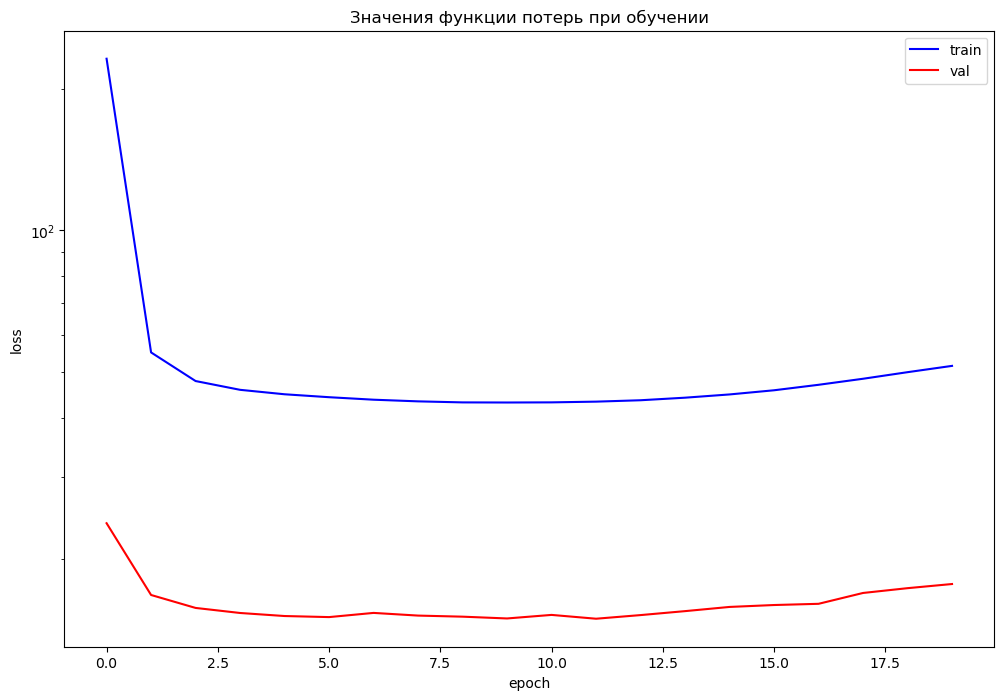

9.52616043638729

In [312]:
last_cand = BatchNormNet().to(device)
optimizer = torch.optim.Adam(last_cand.parameters(), lr=1e-5, weight_decay=1e-2)
cand_train_losses, cand_val_losses = train(last_cand, optimizer, criterion, train_loader, val_loader, epochs=20)
plot_losses(cand_train_losses, cand_val_losses, (8,4))
calculate_rmse(last_cand)

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ при подборе lr лучшее качество получилось на наименьшем из представленных вариантов. Это значит, что модель в любом случае успевает обучиться, и в других вариантах она прыгала вокруг минимума под конец, и меньший lr помог ей к нему приблизиться.

Что же касается weight decay, то слишком малые значения даже уменьшили качество модели. Скорее всего, их было достаточно, чтобы помешать модели хорошо подобрать параметры под выборку, но недостаточно, чтобы остановить переобучение. Поскольку большие значения показали большую эффективность, в качестве доп. эксперимента было решено увеличить его ещё сильнее и посмотреть, продолжит ли увеличение weight_decay, то есть параметра лямбда перед L2-регуляризатором в функции потерь, повышать качество модели.

Ну ладно, как и ожидалось, при настолько большом значении модель слишком увлеклась регуляризацией и забыла про обучение. В общем, лучшее значение - 1е-3.

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаться, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

In [324]:


def train(model, optimizer, criterion, train_loader, val_loader, epochs, scheduler=None, writer=None, patience=0):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
        patience - number of epochs without improvement before early stopping. If 0, no early stopping
    """
    train_losses, val_losses = [], []
    prev_val_loss = float('inf')
    delta = 1e-1
    current_patience = patience
    for epoch in tqdm(range(1, epochs + 1), desc="Epoch"):
        train_loss = training_epoch(model, optimizer, criterion, train_loader)
        val_loss = validation_epoch(model, criterion, val_loader)
        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if writer is not None:
            writer.add_scalar('Loss/train', train_loss, epoch)
            writer.add_scalar('Loss/val', val_loss, epoch)

        if patience > 0:
            if prev_val_loss - val_loss < delta:
                current_patience -= 1
                if current_patience == 0:
                    print(f'Early stopped during epoch {epoch}')
                    break
            else:
                current_patience = patience

            prev_val_loss = val_loss

    return train_losses, val_losses

In [322]:
results = pd.DataFrame(columns=['RMSE'])
results.index.name = 'LR'
lr_options = [1e-3, 1e-4, 1e-5]
for lr in lr_options:
    candidate = BatchNormNet().to(device)
    optimizer = torch.optim.AdamW(candidate.parameters(), lr=lr)
    writer = SummaryWriter(f'logs/bn_net_AdamW_lr={lr}')
    _, _ = train(candidate, optimizer, criterion, train_loader, val_loader, epochs=20, writer=writer, patience=4)
    results.loc[lr] = calculate_rmse(candidate)

results

  0%|          | 0/1510 [00:00<?, ?it/s]

,RMSE
LR,
0.00100,8.715932
0.00010,8.819914
0.00001,8.828940


Перебирать lr это, конечно, здорово, но, может, заменим нужду в этом scheduler-ом?

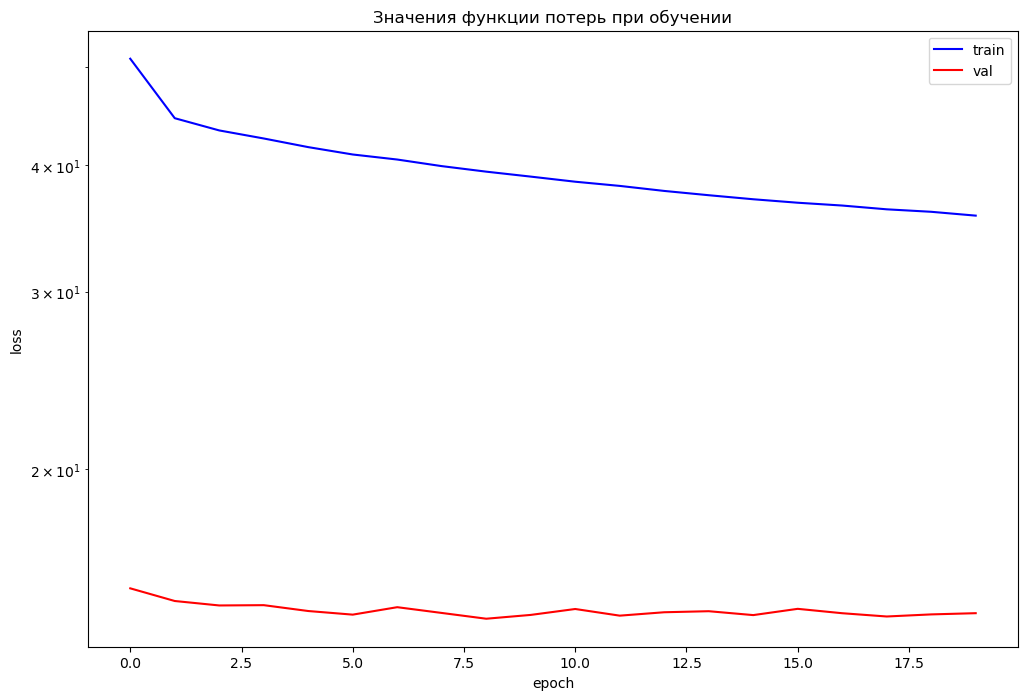

8.861091245170977

In [325]:
EPOCHS = 20
model = BatchNormNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,
                                                max_lr=1e-2,
                                                epochs=EPOCHS,
                                                steps_per_epoch=len(train_loader))
writer = SummaryWriter(f'logs/bn_net_AdamW_scheduler')
scheduled_train_loss, scheduled_val_loss = train(model, optimizer, criterion, train_loader, val_loader, epochs=EPOCHS, scheduler=scheduler, writer=writer, patience=4)
plot_losses(scheduled_train_loss, scheduled_val_loss, (8,4))
calculate_rmse(model)

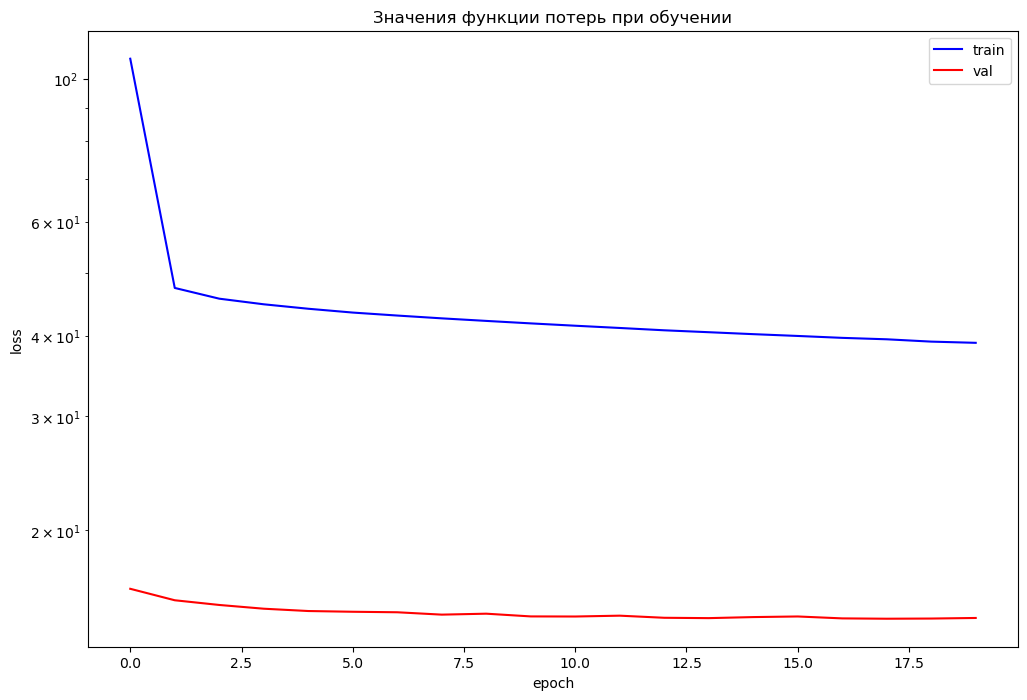

8.843931797984292

In [326]:
EPOCHS = 20
model = BatchNormNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,
                                                max_lr=1e-3, # Разница здесь
                                                epochs=EPOCHS,
                                                steps_per_epoch=len(train_loader))
writer = SummaryWriter(f'logs/bn_net_AdamW_scheduler')
scheduled_train_loss, scheduled_val_loss = train(model, optimizer, criterion, train_loader, val_loader, epochs=EPOCHS, scheduler=scheduler, writer=writer, patience=4)
plot_losses(scheduled_train_loss, scheduled_val_loss, (8,4))
calculate_rmse(model)

Early stopped during epoch 15


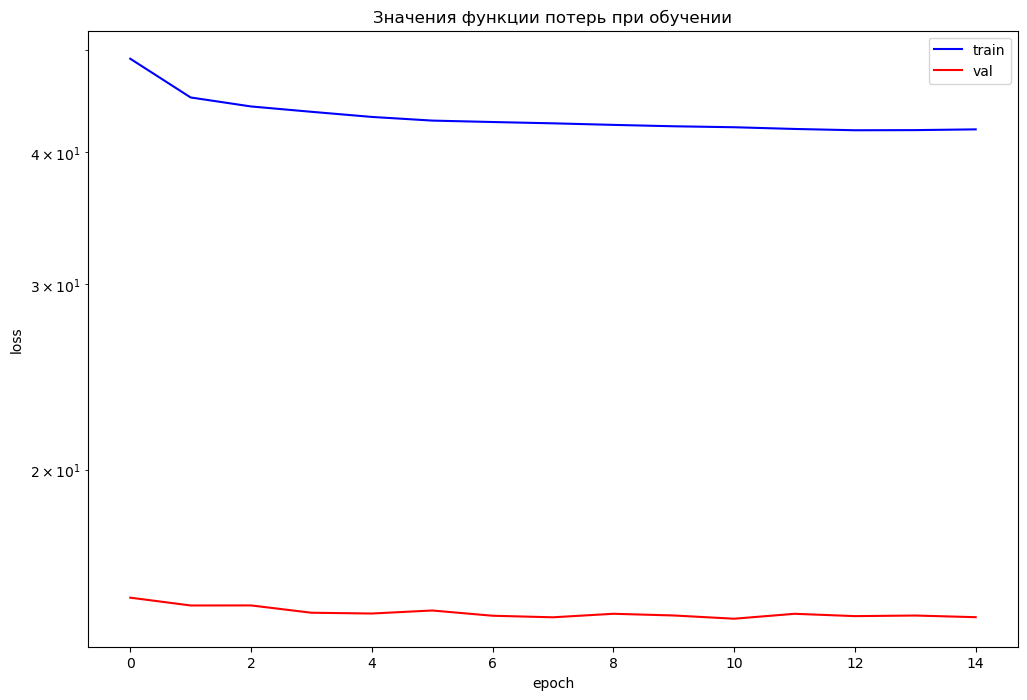

8.688450204090003

In [327]:
EPOCHS = 20
model = BatchNormNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,
                                                max_lr=1e-1, # Разница здесь
                                                epochs=EPOCHS,
                                                steps_per_epoch=len(train_loader))
writer = SummaryWriter(f'logs/bn_net_AdamW_scheduler')
scheduled_train_loss, scheduled_val_loss = train(model, optimizer, criterion, train_loader, val_loader, epochs=EPOCHS, scheduler=scheduler, writer=writer, patience=4)
plot_losses(scheduled_train_loss, scheduled_val_loss, (8,4))
calculate_rmse(model)

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ эксперименты получились интересные.

Сначала я добавил раннюю остановку, но все эксперименты, кроме последнего, так до нее и не дошли.

Затем я решил поменять Adam на улучшенную версию AdamW, и это помогло улучшить результат (до 8.71).

Затем я решил поиграться со scheduler-ами - взял OneCycleLR, и сначала боялся ставить слишком большой максимальный LR, но в результате именно он привел к абсолютно лучшему результату - ещё и помог добиться ранней остановки, так что за 10 эпох он обучился лучше, чем другие за 20. Этот результат и считаем венцом моего творения.

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

__место для картики и эмоции__: это, конечно, было уже в октябре, но и работу я доделываю тогда же, так что вот!! Сходил посмотреть на косплееров, как же я обожаю такие конференции. Пока ещё я не был в костюме принца Мидеймоса, но это только дело времени.
<center>
<img src="https://raw.githubusercontent.com/Bosbobos/IAD/refs/heads/main/DeepLearningBasics/hw01_fcnn/assets/2025-10-10%2017.22.16.jpg" width="600">
</center>
